In [118]:
import pandas as pd

In [119]:
df=pd.read_csv(r'D:\projects\analisis\data\ecommerce_transactions_50000.csv',parse_dates=['order_date'])

In [120]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          50000 non-null  int64         
 1   customer_id       50000 non-null  int64         
 2   order_date        50000 non-null  datetime64[ns]
 3   product_category  50000 non-null  object        
 4   price             50000 non-null  float64       
 5   quantity          50000 non-null  int64         
 6   payment_method    50000 non-null  object        
 7   region            50000 non-null  object        
 8   revenue           50000 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(3)
memory usage: 3.4+ MB


,order_id,customer_id,order_date,product_category,price,quantity,payment_method,region,revenue
0,1,4174,2024-11-04,Clothing,453.84,2,Bank Transfer,Kalimantan,907.68
1,2,4507,2024-02-10,Clothing,460.26,3,Bank Transfer,Sulawesi,1380.78
2,3,1860,2024-05-06,Clothing,34.76,4,Credit Card,Sumatra,139.04
3,4,2294,2024-10-19,Electronics,317.78,1,Credit Card,Sumatra,317.78
4,5,2130,2024-09-10,Clothing,399.21,4,Bank Transfer,Bali,1596.84


tanggal maximum

In [121]:
analysis_date=df['order_date'].max()

hitung rfm

In [122]:
rfm=df.groupby('customer_id').agg(
    recency=('order_date',lambda x:(analysis_date-x.max()).days),
    frequency=('order_id','count'),
    monetary=('revenue','sum' )
).reset_index()

In [123]:
rfm.info()
rfm.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  4000 non-null   int64  
 1   recency      4000 non-null   int64  
 2   frequency    4000 non-null   int64  
 3   monetary     4000 non-null   float64
dtypes: float64(1), int64(3)
memory usage: 125.1 KB


,customer_id,recency,frequency,monetary
0,1000,76,10,7037.08
1,1001,30,10,5747.07
2,1002,20,8,3924.16
3,1003,8,11,6526.06
4,1004,36,8,4431.34


segmenetasi by quantile 5 classes

In [124]:
rfm["R_score"] = pd.qcut(rfm["recency"], 5, labels=[5,4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1,2,3,4,5])
rfm["M_score"] = pd.qcut(rfm["monetary"], 5, labels=[1,2,3,4,5])

In [125]:
rfm["R_score"] = rfm["R_score"].astype(str)
rfm["F_score"] = rfm["F_score"].astype(str)
rfm["M_score"] = rfm["M_score"].astype(str)


In [126]:
rfm.info()
rfm.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  4000 non-null   int64  
 1   recency      4000 non-null   int64  
 2   frequency    4000 non-null   int64  
 3   monetary     4000 non-null   float64
 4   R_score      4000 non-null   object 
 5   F_score      4000 non-null   object 
 6   M_score      4000 non-null   object 
dtypes: float64(1), int64(3), object(3)
memory usage: 218.9+ KB


,customer_id,recency,frequency,monetary,R_score,F_score,M_score
0,1000,76,10,7037.08,1,2,3
1,1001,30,10,5747.07,2,2,2
2,1002,20,8,3924.16,3,1,1
3,1003,8,11,6526.06,4,2,2
4,1004,36,8,4431.34,2,1,1


In [127]:
def fungsi(x):
    if x['R_score']=='5' and x['F_score']=='5':
        return 'loyal customer'
    elif x['R_score']=='5':
        return 'recently customer'
    elif x['F_score']=='5':
        return 'frequenct customer'
    else:
        return 'relugar customer'

In [128]:
rfm['segment']=rfm.apply(fungsi,axis=1)

In [129]:
rfm['segment'].value_counts()

segment
relugar customer      2605
recently customer      595
frequenct customer     588
loyal customer         212
Name: count, dtype: int64

<Axes: xlabel='segment'>

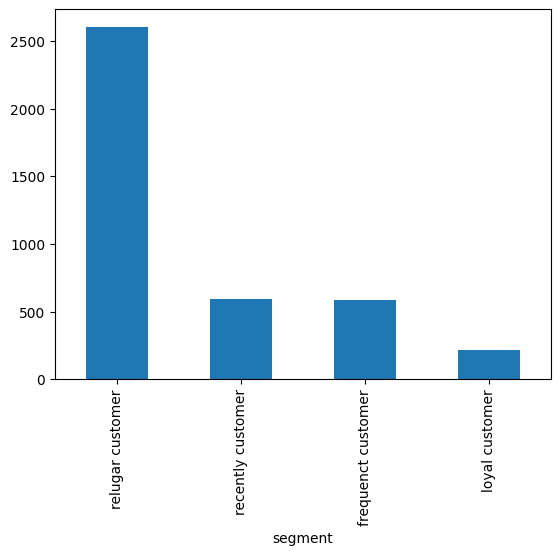

In [133]:
rfm['segment'].value_counts().sort_values(ascending=False).plot(kind='bar')